<a href="https://colab.research.google.com/github/bhargavigoud14/Face_Detection/blob/main/FaceDetect.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install -q deepface


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.2/87.2 kB 2.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.6/108.6 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.0/85.0 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 34.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 48.5 MB/s eta 0:00:00


In [ ]:
from google.colab import files

uploaded = files.upload()

Saving modi.jpg to modi (1).jpg


In [ ]:
import os

# List files in the current directory to check if the images were uploaded
uploaded_files = os.listdir()
print(uploaded_files)


['.config', 'image2 (1).jpg', 'image2.jpg', '\u202bimage1.jpg', 'virat2 (1).jpg', 'virat1 (1).jpg', 'virat2.jpg', 'virat1.jpg', 'image1.jpg', 'sample_data']


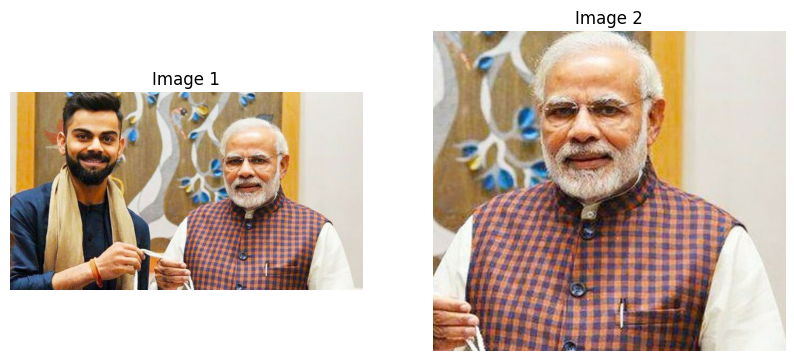

✅ Faces match with 98.33% confidence.


In [ ]:
from deepface import DeepFace
import matplotlib.pyplot as plt
import cv2
import os

# Function to compare faces and handle edge cases
def compare_faces(img1_path, img2_path):
    # Check if both images exist
    if not os.path.exists(img1_path) or not os.path.exists(img2_path):
        print("❌ One or both image files do not exist.")
        return

    # Load images
    img1 = cv2.imread(img1_path)
    img2 = cv2.imread(img2_path)

    # Check if images are loaded properly
    if img1 is None or img2 is None:
        print("❌ Error: One or both images could not be loaded.")
        return

    # Convert images to RGB for display
    img1_rgb = cv2.cvtColor(img1, cv2.COLOR_BGR2RGB)
    img2_rgb = cv2.cvtColor(img2, cv2.COLOR_BGR2RGB)

    # Show both images
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(img1_rgb)
    plt.title("Image 1")
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(img2_rgb)
    plt.title("Image 2")
    plt.axis('off')
    plt.show()

    # Compare faces using DeepFace
    try:
        result = DeepFace.verify(img1_path, img2_path, model_name='VGG-Face')
    except Exception as e:
        print(f"❌ Error in face comparison ,image is not clear to compare or ❌ Face not found in one or both images.: {e}")
        return

    # Calculate similarity score
    similarity = (1 - result['distance']) * 100
    similarity = max(0, min(similarity, 100))

    # Display result based on similarity
    if result['verified']:
        print(f"✅ Faces match with {similarity:.2f}% confidence.")
    else:
        print(f"❌ Faces do NOT match. Similarity: {similarity:.2f}%")

# Replace with your actual file names or paths if needed
compare_faces("kohli_modi.jpg", "modi.jpg")
